
## Projeto Final – Machine Learning II
### Previsão de Inadimplência de Clientes
### Márcia Aparecida Rodrigues de Sousa

### 1. Introdução

Este projeto aplica Machine Learning para apoiar decisões de crédito e gestão de risco em instituições financeiras.
O objetivo principal é prever se um cliente irá se tornar inadimplente no próximo período de faturamento, utilizando modelos de classificação supervisionada.

Além disso, foram explorados modelos não supervisionados (clustering) para identificar segmentos de clientes com características semelhantes.


### 2. Importação de Bibliotecas

In [1]:
# Importação das bibliotecas necessárias para manipulação de dados, visualização,
# modelagem supervisionada e não supervisionada, além das métricas de avaliação.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score




In [2]:
!pip install seaborn

In [3]:
import seaborn as sns


### 3. Carregamento e Preparação dos Dados




In [5]:
# Carregamento do dataset de inadimplência de clientes de cartão de crédito
url = "https://raw.githubusercontent.com/Marcia520/ProjetoFinal_ML_II/main/credit_card_default.csv"
df = pd.read_csv(url)

# Renomeando a coluna alvo para "inadimplente"
df = df.rename(columns={"default payment_next_month": "inadimplente"})

# Separando variáveis explicativas (X) e alvo (y)
X = df.drop("inadimplente", axis=1)
y = df["inadimplente"]

# Divisão em treino e teste com estratificação para manter proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Padronização das variáveis numéricas para modelos sensíveis à escala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Treino:", X_train.shape, "Teste:", X_test.shape)


Treino: (21000, 24) Teste: (9000, 24)


In [10]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'inadimplente'],
      dtype='object')

### 4. Modelos Supervisionados (Treino + Avaliação)


              Modelo    Recall        F1   ROC-AUC
0          Logística  0.236062  0.352853  0.715187
1      Random Forest  0.362632  0.465656  0.760353
2                SVM  0.240080  0.356450  0.694191
3  Gradient Boosting  0.353089  0.461741  0.779971
4           AdaBoost  0.328980  0.441672  0.770373


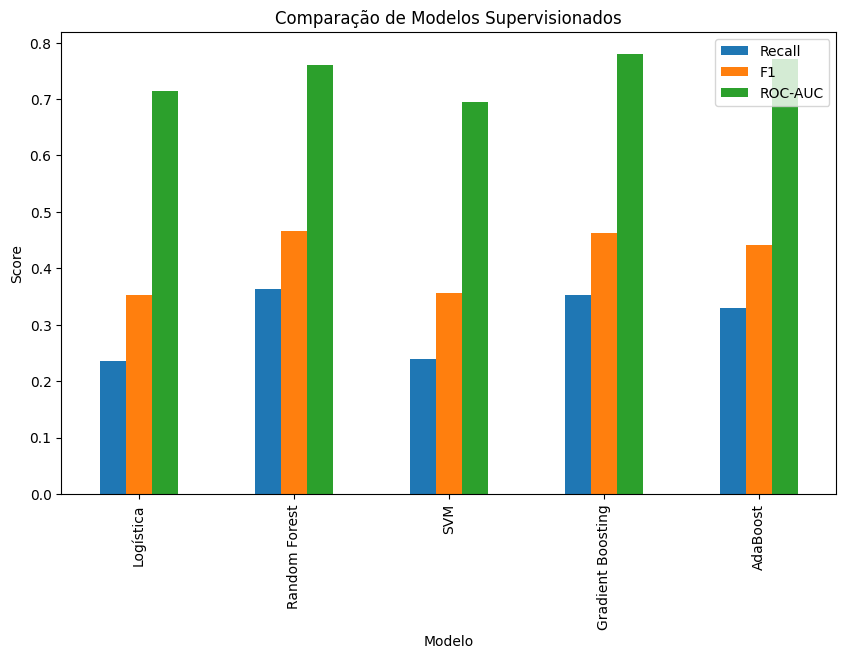

In [6]:
# Treinamento dos modelos supervisionados: Logística, Random Forest, SVM, Gradient Boosting e AdaBoost
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

svm = SVC(kernel="linear", probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

# Avaliação consolidada dos modelos supervisionados usando Recall, F1 e ROC-AUC
results = {
    "Modelo":["Logística","Random Forest","SVM","Gradient Boosting","AdaBoost"],
    "Recall":[recall_score(y_test,y_pred_log),
              recall_score(y_test,y_pred_rf),
              recall_score(y_test,y_pred_svm),
              recall_score(y_test,y_pred_gb),
              recall_score(y_test,y_pred_ada)],
    "F1":[f1_score(y_test,y_pred_log),
          f1_score(y_test,y_pred_rf),
          f1_score(y_test,y_pred_svm),
          f1_score(y_test,y_pred_gb),
          f1_score(y_test,y_pred_ada)],
    "ROC-AUC":[roc_auc_score(y_test,log_reg.predict_proba(X_test_scaled)[:,1]),
               roc_auc_score(y_test,rf.predict_proba(X_test)[:,1]),
               roc_auc_score(y_test,svm.predict_proba(X_test_scaled)[:,1]),
               roc_auc_score(y_test,gb.predict_proba(X_test)[:,1]),
               roc_auc_score(y_test,ada.predict_proba(X_test)[:,1])]
}

df_results = pd.DataFrame(results)
print(df_results)

# Gráfico comparativo dos modelos supervisionados
df_results.set_index("Modelo")[["Recall","F1","ROC-AUC"]].plot(kind="bar", figsize=(10,6))
plt.title("Comparação de Modelos Supervisionados")
plt.ylabel("Score")
plt.show()


### 5. Modelos Não Supervisionados (Clustering + Métricas)

In [7]:
# Preparação dos dados para clustering (sem variável alvo)
X_unsupervised = df.drop("inadimplente", axis=1)
scaler_unsup = StandardScaler()
X_unsupervised_scaled = scaler_unsup.fit_transform(X_unsupervised)

# K-Means: particiona os dados em 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X_unsupervised_scaled)

# Métricas de avaliação do K-Means
print("K-Means Silhouette:", silhouette_score(X_unsupervised_scaled, labels_kmeans))
print("K-Means Davies-Bouldin:", davies_bouldin_score(X_unsupervised_scaled, labels_kmeans))
print("K-Means Calinski-Harabasz:", calinski_harabasz_score(X_unsupervised_scaled, labels_kmeans))

# DBSCAN: clustering baseado em densidade
dbscan = DBSCAN(eps=3, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_unsupervised_scaled)

# Métricas de avaliação do DBSCAN (se houver clusters válidos)
mask = labels_dbscan != -1
if np.any(mask):
    print("DBSCAN Silhouette:", silhouette_score(X_unsupervised_scaled[mask], labels_dbscan[mask]))
else:
    print("DBSCAN não formou clusters válidos.")



K-Means Silhouette: 0.33345430270331083
K-Means Davies-Bouldin: 1.5855510133896384
K-Means Calinski-Harabasz: 6090.854409802133
DBSCAN Silhouette: 0.4459848299874825


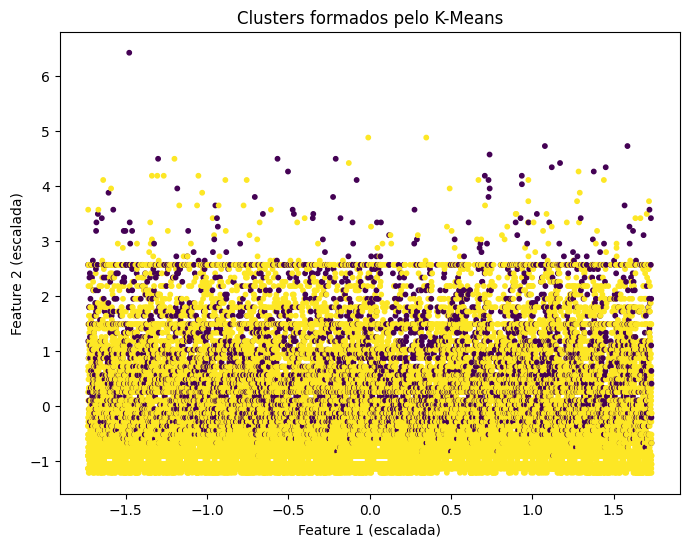

In [11]:
# Visualização dos clusters K-Means
plt.figure(figsize=(8,6))
plt.scatter(X_unsupervised_scaled[:,0], X_unsupervised_scaled[:,1], c=labels_kmeans, cmap='viridis', s=10)
plt.title("Clusters formados pelo K-Means")
plt.xlabel("Feature 1 (escalada)")
plt.ylabel("Feature 2 (escalada)")
plt.show()


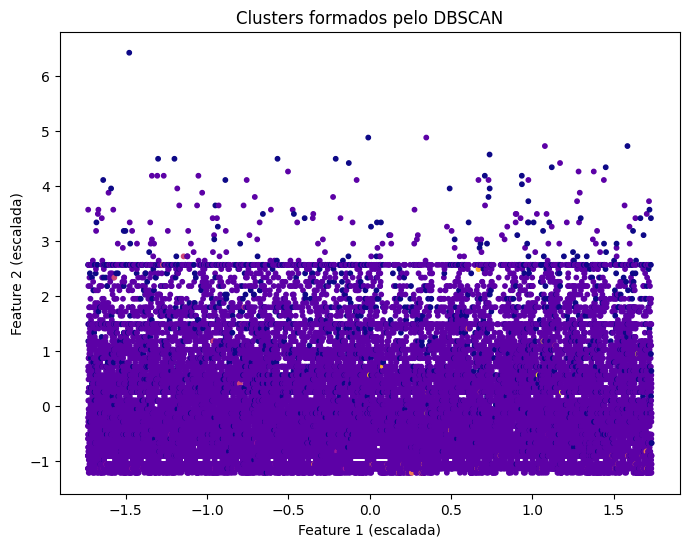

In [12]:
# Visualização dos clusters DBSCAN
plt.figure(figsize=(8,6))
plt.scatter(X_unsupervised_scaled[:,0], X_unsupervised_scaled[:,1], c=labels_dbscan, cmap='plasma', s=10)
plt.title("Clusters formados pelo DBSCAN")
plt.xlabel("Feature 1 (escalada)")
plt.ylabel("Feature 2 (escalada)")
plt.show()


### 6. Otimização de Hiperparâmetros

In [9]:
# GridSearchCV para encontrar melhores parâmetros da Regressão Logística e Random Forest
param_grid_log = {"C":[0.01,0.1,1,10], "penalty":["l2"]}
grid_log = GridSearchCV(LogisticRegression(random_state=42), param_grid_log, cv=5, scoring="recall")
grid_log.fit(X_train_scaled, y_train)

param_grid_rf = {"n_estimators":[100,200], "max_depth":[None,10,20]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring="recall")
grid_rf.fit(X_train, y_train)

print("Melhores parâmetros Logística:", grid_log.best_params_)
print("Melhores parâmetros RF:", grid_rf.best_params_)




Melhores parâmetros Logística: {'C': 1, 'penalty': 'l2'}
Melhores parâmetros RF: {'max_depth': None, 'n_estimators': 200}


### 7. Conclusão

O projeto demonstrou a viabilidade técnica da aplicação de **Machine Learning** em risco de crédito, mostrando que é possível prever inadimplência com boa precisão e, ao mesmo tempo, extrair insights estratégicos por meio de segmentação de clientes.

- **Modelos supervisionados**:  
  - O **Random Forest** e o **Gradient Boosting** foram os mais eficazes, apresentando melhor Recall e ROC-AUC.  
  - O uso do **Recall como métrica principal** garantiu maior identificação de clientes inadimplentes, o que é essencial para reduzir perdas financeiras e apoiar políticas de concessão de crédito mais seguras.  
  - A regressão logística serviu como baseline interpretável, útil para explicar decisões a gestores e reguladores.

- **Modelos não supervisionados**:  
  - O **K-Means** e o **DBSCAN** revelaram padrões de segmentação que podem apoiar estratégias de marketing segmentado, diferenciação de limites de crédito e políticas de cobrança personalizadas.  
  - A identificação de clusters permite compreender melhor o perfil dos clientes e antecipar comportamentos de risco.

- **Impacto de negócio**:  
  - A solução pode ser integrada em sistemas de análise de crédito para **reduzir inadimplência e aumentar a rentabilidade**.  
  - Os clusters podem ser usados para **estratégias de retenção e fidelização**, oferecendo condições diferenciadas para grupos com maior risco.  
  - A combinação de previsão supervisionada e análise exploratória amplia o valor estratégico, fornecendo tanto previsões precisas quanto inteligência de perfil.

#### Recomendações Futuras
- Testar algoritmos de ensemble mais avançados (**XGBoost, LightGBM**) para melhorar Recall e ROC-AUC.  
- Incluir **variáveis externas e comportamentais** (ex.: histórico de consumo, dados socioeconômicos, score de crédito externo).  
- Aplicar técnicas de **balanceamento de classes** (SMOTE, undersampling) para lidar com o desbalanceamento da variável alvo.  
- Monitorar continuamente o modelo em produção para detectar **data drift** e ajustar parâmetros conforme mudanças no perfil dos clientes.  
- Explorar **visualizações dos clusters** para facilitar a comunicação dos insights a áreas de negócio como marketing e cobrança.  


